# UCI Online Retail 연관규칙 분석

**UCI Online Retail** 데이터셋에 대해 다음 과정을 수행합니다.

1. 데이터 수집
2. 거래 데이터 전처리
3. One-Hot Encoding
4. Support 계산
5. Confidence 계산
6. Lift 계산
7. 규칙 생성
8. 추천 상품 도출
9. 시각화
10. 결과 보고서 작성

거래 데이터를 장바구니 단위로 변환한 뒤 support를 계산하고, Apriori 방식으로 frequent itemset과 association rule을 생성합니다.

## 1. 환경 설정 및 라이브러리 로드

- Python, PyTorch, CPU/GPU 사용 가능 여부 확인
- 결과 저장 폴더 생성
- 시각화 기본 스타일 지정

### CUDA 사용 방식

이 노트북은 단순히 `torch.cuda.is_available()`로 CUDA 존재 여부만 확인하는 것이 아니라, `X` 텐서 자체를 `cuda`로 옮겨서 지원하는 경우 GPU에서 연산하도록 구성합니다. 다만 support 계산은 데이터셋 크기와 반복 구조 때문에 CPU가 더 빠를 수도 있어, 큰 배치나 대규모 후보가 아니면 GPU 이점이 제한적일 수 있습니다.

In [1]:
# 파이썬 인터프리터 및 실행 환경 정보를 확인하기 위한 표준 라이브러리를 불러옵니다.
import sys
# 파일/폴더 경로 처리 및 디렉터리 생성 같은 운영체제 수준 작업을 위해 불러옵니다.
import os
# UCI에서 내려받은 zip 압축 파일을 열고 내부 파일을 추출하기 위해 사용합니다.
import zipfile
# 웹 URL로부터 데이터 파일을 다운로드하기 위해 사용합니다.
import urllib.request
# 현재 시스템의 CPU 코어 수를 확인하기 위해 multiprocessing 모듈을 사용합니다.
import multiprocessing as mp
# itemset에서 가능한 부분집합(lhs)을 만들기 위해 조합 함수를 불러옵니다.
from itertools import combinations

# 수치 계산과 배열 처리를 위해 NumPy를 불러옵니다.
import numpy as np
# 표 형태 데이터 처리와 집계, 정렬, 출력에 사용할 pandas를 불러옵니다.
import pandas as pd
# One-Hot 텐서 생성과 support 계산을 위한 PyTorch를 불러옵니다.
import torch
# 그래프를 그리기 위한 matplotlib의 pyplot 모듈을 불러옵니다.
import matplotlib.pyplot as plt
# matplotlib 기반의 보기 좋은 시각화 스타일을 적용하기 위해 seaborn을 불러옵니다.
import seaborn as sns

# 현재 실행 중인 파이썬 버전을 출력해 실행 환경을 확인합니다.
print('Python version:', sys.version)
# 현재 설치된 PyTorch 버전을 출력해 라이브러리 버전을 기록합니다.
print('PyTorch version:', torch.__version__)
# GPU(CUDA) 사용 가능 여부를 출력해 연산 장치를 확인합니다.
print('CUDA available:', torch.cuda.is_available())
# 시스템에서 사용 가능한 CPU 코어 수를 출력합니다.
print('CPU count:', mp.cpu_count())

# 시각화 전체에 흰색 격자 스타일을 적용해 그래프 가독성을 높입니다.
plt.style.use('seaborn-v0_8-whitegrid')
# seaborn의 Set2 팔레트를 기본 색상 테마로 지정합니다.
sns.set_palette('Set2')

OUTPUT_DIR = 'output_online_retail'
# 작업 폴더가 없으면 생성하고, 이미 있으면 에러 없이 그대로 사용합니다.
os.makedirs(OUTPUT_DIR, exist_ok=True)

# UCI Online Retail 데이터셋 zip 파일의 다운로드 URL을 지정합니다.
DATA_URL = 'https://archive.ics.uci.edu/static/public/352/online+retail.zip'
# 내려받은 zip 파일을 저장할 로컬 경로를 설정합니다.
ZIP_PATH = os.path.join(OUTPUT_DIR, 'online_retail.zip')
# zip 내부에서 추출한 Excel 원본 파일의 저장 경로를 설정합니다.
XLSX_PATH = os.path.join(OUTPUT_DIR, 'Online Retail.xlsx')
# 텍스트 보고서를 저장하던 경로를 정의합니다. 화면 출력 버전에서도 경로 변수는 남아 있을 수 있습니다.
REPORT_PATH = os.path.join(OUTPUT_DIR, 'report.txt')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('DEVICE:', DEVICE)

Python version: 3.13.13 | packaged by Anaconda, Inc. | (main, Apr 14 2026, 06:12:50) [MSC v.1942 64 bit (AMD64)]
PyTorch version: 2.12.0+cu132
CUDA available: True
CPU count: 16
DEVICE: cuda


## 2. 데이터 수집

UCI 저장소에서 Online Retail 압축 파일을 내려받고, 내부의 Excel 파일을 추출합니다.

In [2]:
# Excel 원본 파일이 아직 없으면 UCI 저장소에서 zip 파일을 내려받고 내부 Excel 파일을 추출합니다.
if not os.path.exists(XLSX_PATH):
    print('데이터 다운로드 중...')
    urllib.request.urlretrieve(DATA_URL, ZIP_PATH)
# 다운로드한 zip 파일을 열어 내부에 들어 있는 원본 Excel 파일을 찾습니다.
    with zipfile.ZipFile(ZIP_PATH, 'r') as zf:
# zip 내부 파일 목록을 순회하며 Excel 파일 이름을 확인합니다.
        for name in zf.namelist():
# 확장자가 .xlsx인 파일만 골라 실제 원본 데이터 파일로 사용합니다.
            if name.lower().endswith('.xlsx'):
# zip 내부 Excel 파일을 읽어 로컬 경로에 그대로 저장합니다.
                with zf.open(name) as f_in, open(XLSX_PATH, 'wb') as f_out:
                    f_out.write(f_in.read())
    print('다운로드 및 압축 해제 완료')
else:
    print('기존 파일 사용:', XLSX_PATH)

# 추출한 Excel 파일을 pandas DataFrame으로 읽어 원본 데이터를 메모리에 적재합니다.
raw_df = pd.read_excel(XLSX_PATH)
# 데이터 크기(shape)를 출력해 전처리 전후 또는 중간 결과의 규모를 확인합니다.
print('원본 데이터 shape:', raw_df.shape)
raw_df.head()

기존 파일 사용: output_online_retail\Online Retail.xlsx
원본 데이터 shape: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


## 3. 거래 데이터 전처리

전처리 기준:
- `Description`, `CustomerID` 결측 제거
- `InvoiceNo`가 `C`로 시작하는 취소 거래 제거
- `Quantity > 0`, `UnitPrice > 0` 조건 유지
- `Description` 정리 및 대문자화
- `Country == 'United Kingdom'`만 사용
- `InvoiceNo` 기준 basket 생성

In [3]:
# 원본 데이터를 보존하기 위해 복사본을 만들어 전처리를 진행합니다.
df = raw_df.copy()
# 컬럼명 앞뒤 공백을 제거해 컬럼 접근 오류를 방지합니다.
df.columns = [c.strip() for c in df.columns]

# 상품명과 고객 ID가 없는 행은 거래 해석이 어렵기 때문에 제거합니다.
df = df.dropna(subset=['Description', 'CustomerID'])
# InvoiceNo를 문자열로 바꿔 취소 거래 식별 접두어(C) 확인이 가능하게 합니다.
df['InvoiceNo'] = df['InvoiceNo'].astype(str)
# InvoiceNo가 C로 시작하는 취소 거래를 제거합니다.
df = df[~df['InvoiceNo'].str.startswith('C', na=False)]
# 수량과 단가가 양수인 정상 거래만 남깁니다.
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]
# 상품명을 문자열로 통일하고 공백 제거 및 대문자화해 같은 상품을 일관되게 처리합니다.
df['Description'] = df['Description'].astype(str).str.strip().str.upper()
# 국가를 영국으로 제한해 대표적인 basket analysis 예제 형태로 맞춥니다.
df = df[df['Country'] == 'United Kingdom'].copy()

# 데이터 크기(shape)를 출력해 전처리 전후 또는 중간 결과의 규모를 확인합니다.
print('전처리 후 shape:', df.shape)

# 같은 송장 번호(InvoiceNo)에 속한 상품들을 하나의 장바구니 거래로 묶습니다.
basket_series = df.groupby('InvoiceNo')['Description'].apply(lambda x: sorted(set(x)))
# 상품이 2개 이상 포함된 거래만 남겨 연관규칙 분석이 가능하도록 합니다.
basket_series = basket_series[basket_series.apply(len) >= 2]
# 장바구니 Series를 파이썬 리스트 형태의 거래 목록으로 변환합니다.
transactions = basket_series.tolist()

print('거래 수:', len(transactions))
print('예시 거래 5개:')
# 거래 예시를 몇 개 출력해 basket 형태가 올바르게 생성되었는지 확인합니다.
for i, tx in enumerate(transactions[:5], start=1):
    print(i, tx[:10], '...' if len(tx) > 10 else '')

전처리 후 shape: (354321, 8)
거래 수: 15373
예시 거래 5개:
1 ['CREAM CUPID HEARTS COAT HANGER', 'GLASS STAR FROSTED T-LIGHT HOLDER', 'KNITTED UNION FLAG HOT WATER BOTTLE', 'RED WOOLLY HOTTIE WHITE HEART.', 'SET 7 BABUSHKA NESTING BOXES', 'WHITE HANGING HEART T-LIGHT HOLDER', 'WHITE METAL LANTERN'] 
2 ['HAND WARMER RED POLKA DOT', 'HAND WARMER UNION JACK'] 
3 ['ASSORTED COLOUR BIRD ORNAMENT', 'BOX OF 6 ASSORTED COLOUR TEASPOONS', 'BOX OF VINTAGE ALPHABET BLOCKS', 'BOX OF VINTAGE JIGSAW BLOCKS', 'DOORMAT NEW ENGLAND', 'FELTCRAFT PRINCESS CHARLOTTE DOLL', 'HOME BUILDING BLOCK WORD', 'IVORY KNITTED MUG COSY', 'LOVE BUILDING BLOCK WORD', "POPPY'S PLAYHOUSE BEDROOM"] ...
4 ['BLUE COAT RACK PARIS FASHION', 'JAM MAKING SET WITH JARS', 'RED COAT RACK PARIS FASHION', 'YELLOW COAT RACK PARIS FASHION'] 
5 ['HAND WARMER RED POLKA DOT', 'HAND WARMER UNION JACK'] 


## 4. 빈발 상품 선택 및 One-Hot Encoding

원본 데이터는 상품 수가 많아 전체 조합 계산 비용이 큽니다. 따라서 **상위 빈발 상품만 선택**한 뒤 One-hot 텐서를 생성합니다.

In [4]:
# 계산량을 줄이기 위해 분석에 사용할 상위 빈발 상품 개수를 지정합니다.
TOP_N_ITEMS = 120

# 모든 거래의 상품을 한 줄로 펼쳐 전체 빈도 계산용 Series를 만듭니다.
all_items = pd.Series([item for tx in transactions for item in tx])
# 각 상품이 전체 거래에서 몇 번 등장했는지 빈도를 계산합니다.
item_counts = all_items.value_counts()
# 빈도가 높은 상위 TOP_N_ITEMS개의 상품만 분석 대상으로 선택합니다.
selected_items = item_counts.head(TOP_N_ITEMS).index.tolist()

# 선택된 상품만 포함하도록 필터링한 거래를 저장할 리스트를 준비합니다.
filtered_transactions = []
# 각 거래를 순회하며 상위 빈발 상품만 남긴 필터링 거래를 생성합니다.
for tx in transactions:
# 현재 거래에서 선택된 상품만 남기고 중복을 제거한 뒤 정렬합니다.
    items = sorted(set([item for item in tx if item in selected_items]))
# 필터링 후에도 상품이 2개 이상 남은 거래만 유지합니다.
    if len(items) >= 2:
# 조건을 만족한 거래를 최종 분석 대상 리스트에 추가합니다.
        filtered_transactions.append(items)

# 필터링 후 남은 거래 수를 계산합니다.
num_transactions = len(filtered_transactions)
# 분석 대상 상품 수를 계산합니다.
num_items = len(selected_items)

# 상품명을 텐서 열 인덱스로 변환하기 위한 사전을 생성합니다.
item_to_idx = {item: idx for idx, item in enumerate(selected_items)}
# 인덱스를 다시 상품명으로 복원하기 위한 역방향 사전을 생성합니다.
idx_to_item = {idx: item for item, idx in item_to_idx.items()}

X = torch.zeros((num_transactions, num_items), dtype=torch.float32, device=DEVICE)
# 각 거래(row)에 대해 포함된 상품 위치를 1로 표시합니다.
for row_idx, tx in enumerate(filtered_transactions):
# 현재 거래 안의 각 상품을 순회합니다.
    for item in tx:
# 해당 상품이 존재하는 열 위치를 1로 설정해 One-Hot Encoding을 완성합니다.
        X[row_idx, item_to_idx[item]] = 1.0

# 동시 구매 여부 계산을 빠르게 하기 위해 boolean 텐서로 변환합니다.
X_bool = X.to(torch.bool)

print('필터링 거래 수:', num_transactions)
print('선택 상품 수:', num_items)
# 데이터 크기(shape)를 출력해 전처리 전후 또는 중간 결과의 규모를 확인합니다.
print('One-Hot tensor shape:', X.shape)
print('상위 10개 상품:')
print(selected_items[:10])

필터링 거래 수: 11386
선택 상품 수: 120
One-Hot tensor shape: torch.Size([11386, 120])
상위 10개 상품:
['WHITE HANGING HEART T-LIGHT HOLDER', 'JUMBO BAG RED RETROSPOT', 'REGENCY CAKESTAND 3 TIER', 'ASSORTED COLOUR BIRD ORNAMENT', 'PARTY BUNTING', 'LUNCH BAG RED RETROSPOT', 'SET OF 3 CAKE TINS PANTRY DESIGN', 'LUNCH BAG  BLACK SKULL.', "PAPER CHAIN KIT 50'S CHRISTMAS", 'NATURAL SLATE HEART CHALKBOARD']


## GPU/CPU 동작 확인

아래 셀에서 텐서가 실제로 어느 디바이스에 올라갔는지 확인합니다. `X.device`가 `cuda:0`이면 실제 GPU 메모리에서 연산합니다.

In [5]:
print('X.device:', X.device)
print('X_bool.device:', X_bool.device)
if torch.cuda.is_available():
    print('CUDA memory allocated (MB):', torch.cuda.memory_allocated(0) / 1024**2)

X.device: cuda:0
X_bool.device: cuda:0
CUDA memory allocated (MB): 6.515625


## 5. 1-item Support 계산

Support는 전체 거래 중 특정 상품이 등장한 비율입니다.

In [6]:
# 열 방향 평균을 구해 각 상품의 support를 계산합니다.
item_support_tensor = X.mean(dim=0).cpu()
# 상품명, support, 등장 횟수를 한 번에 보기 위한 DataFrame으로 정리합니다.
item_support_df = pd.DataFrame({
    'item': selected_items,
    'support': item_support_tensor.numpy(),
    'count': (item_support_tensor * num_transactions).to(torch.int64).numpy()
}).sort_values('support', ascending=False).reset_index(drop=True)

item_support_df.head(15)

,item,support,count
0,WHITE HANGING HEART T-LIGHT HOLDER,0.158791,1808
1,JUMBO BAG RED RETROSPOT,0.123661,1408
2,REGENCY CAKESTAND 3 TIER,0.114878,1308
3,ASSORTED COLOUR BIRD ORNAMENT,0.108027,1230
4,PARTY BUNTING,0.106183,1209
5,LUNCH BAG RED RETROSPOT,0.097664,1112
6,LUNCH BAG BLACK SKULL.,0.086685,986
7,SET OF 3 CAKE TINS PANTRY DESIGN,0.085280,970
8,PAPER CHAIN KIT 50'S CHRISTMAS,0.079132,901
9,HEART OF WICKER SMALL,0.079044,900


## 6. 시각화: 상위 상품 Support

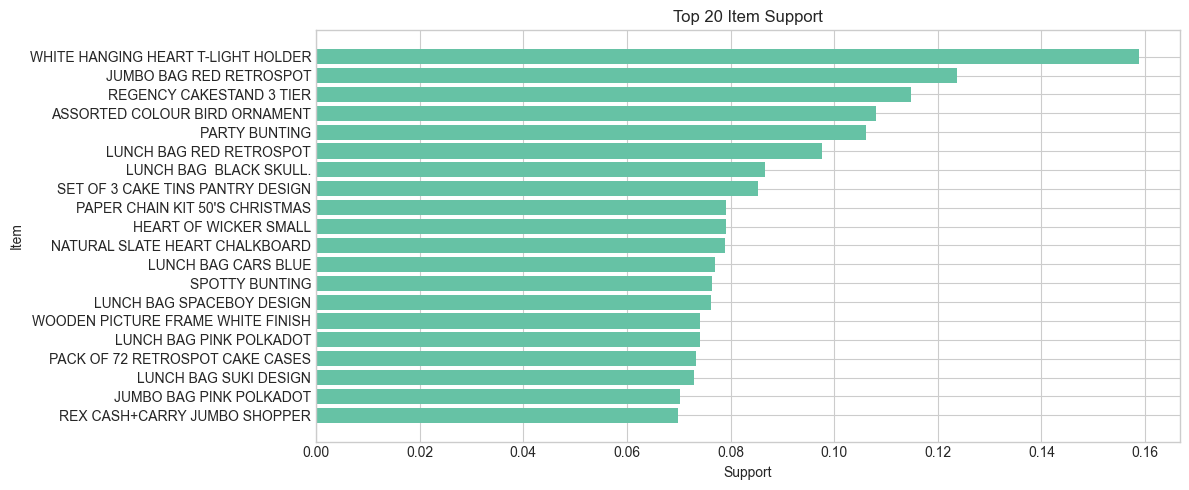

In [7]:
# 새로운 matplotlib figure를 생성해 현재 시각화를 시작합니다.
plt.figure(figsize=(12, 5))
# 상위 20개 상품을 보기 좋게 세로 막대그래프 순서에 맞춰 역순으로 정렬합니다.
plot_df = item_support_df.head(20).iloc[::-1]
# 수평 막대그래프로 support 크기를 시각화합니다.
plt.barh(plot_df['item'], plot_df['support'])
plt.title('Top 20 Item Support')
plt.xlabel('Support')
plt.ylabel('Item')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'top20_item_support.png'), dpi=150)
plt.show()

## 7. 거래 행렬 시각화

희소한 one-hot 거래행렬의 일부를 시각화합니다.

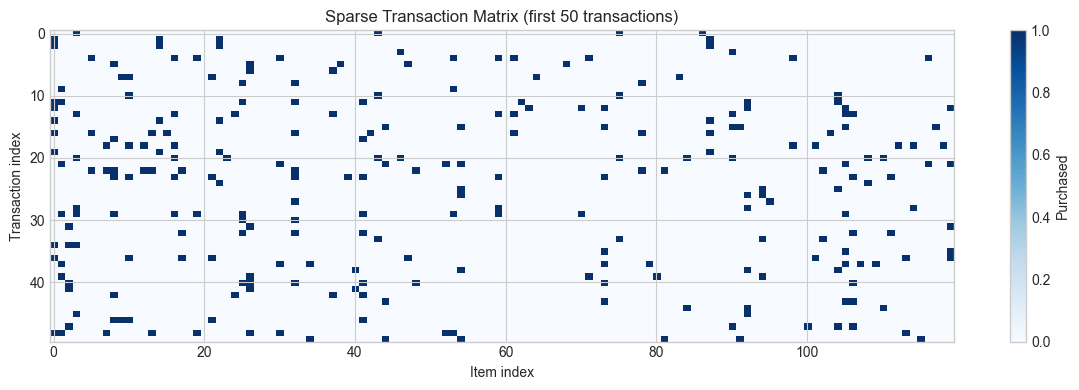

In [8]:
# 새로운 matplotlib figure를 생성해 현재 시각화를 시작합니다.
plt.figure(figsize=(12, 4))
# 희소한 거래행렬을 이미지처럼 시각화해 구매 패턴 분포를 확인합니다.
plt.imshow(X[:50].cpu().numpy(), aspect='auto', cmap='Blues')
plt.title('Sparse Transaction Matrix (first 50 transactions)')
plt.xlabel('Item index')
plt.ylabel('Transaction index')
plt.colorbar(label='Purchased')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'transaction_matrix_first50.png'), dpi=150)
plt.show()

## 8. Itemset support 계산 함수

후보 itemset에 대해 해당 열들을 동시에 만족하는 거래 비율을 계산합니다.

In [9]:
# 주어진 itemset이 모든 거래에서 동시에 등장하는 비율(support)을 계산하는 함수를 정의합니다.
def calculate_itemset_support(itemset, X_bool):
# itemset 튜플을 열 인덱스 리스트로 변환합니다.
    cols = list(itemset)
# itemset에 해당하는 여러 상품 열만 부분 선택합니다.
    selected = X_bool[:, cols]
# 각 거래가 itemset의 모든 상품을 동시에 포함하는지 검사한 뒤 평균으로 support를 계산합니다.
    support = selected.all(dim=1).float().mean().item()
    return support

# 예시
example_itemset = tuple(sorted([0, 1]))
print('예시 itemset:', tuple(idx_to_item[i] for i in example_itemset))
print('support:', calculate_itemset_support(example_itemset, X_bool))

예시 itemset: ('WHITE HANGING HEART T-LIGHT HOLDER', 'JUMBO BAG RED RETROSPOT')
support: 0.021166343241930008


## 9. Apriori 기반 Frequent Itemset 생성

- 1-itemset부터 시작
- 이전 단계 frequent itemset을 join하여 후보 생성
- PyTorch boolean tensor로 support 계산
- minimum support 이상인 itemset만 유지

In [10]:
# frequent itemset으로 인정할 최소 support 기준을 설정합니다.
MIN_SUPPORT = 0.015
# 생성할 최대 itemset 길이를 지정합니다.
MAX_LEN = 4

# frequent itemset과 그 support를 저장할 딕셔너리를 초기화합니다.
frequent_itemsets = {}

# 1-item support 결과를 순회하며 최소 support 이상인 1-itemset을 추립니다.
for idx, row in item_support_df.iterrows():
    item_name = row['item']
    support = float(row['support'])
# minimum support 조건을 만족하는 경우에만 frequent itemset으로 채택합니다.
    if support >= MIN_SUPPORT:
        frequent_itemsets[(item_to_idx[item_name],)] = support

print('1-itemset 개수:', sum(1 for k in frequent_itemsets if len(k) == 1))

# 2-itemset부터 MAX_LEN-itemset까지 단계적으로 후보를 생성합니다.
for k in range(2, MAX_LEN + 1):
# 이전 길이(k-1)의 frequent itemset만 골라 다음 단계 후보 생성에 사용합니다.
    prev_frequents = sorted([itemset for itemset in frequent_itemsets if len(itemset) == k - 1])
# 중복 없는 후보 itemset을 저장하기 위한 set을 초기화합니다.
    candidate_itemsets = set()

# Apriori join을 위해 이전 frequent itemset들을 이중 반복으로 비교합니다.
    for i in range(len(prev_frequents)):
# 같은 prefix를 공유하는 itemset끼리 결합할 두 번째 인덱스를 순회합니다.
        for j in range(i + 1, len(prev_frequents)):
# 첫 번째 frequent itemset 후보를 선택합니다.
            a = prev_frequents[i]
# 두 번째 frequent itemset 후보를 선택합니다.
            b = prev_frequents[j]
# 앞부분(prefix)이 같으면 Apriori join 조건을 만족한다고 보고 결합합니다.
            if a[:-1] == b[:-1]:
# 두 itemset의 합집합을 만들어 새로운 후보 itemset을 생성합니다.
                candidate = tuple(sorted(set(a) | set(b)))
# 생성된 후보 길이가 현재 목표 길이 k와 같을 때만 채택합니다.
                if len(candidate) == k:
# 조건을 만족한 후보 itemset을 set에 추가합니다.
                    candidate_itemsets.add(candidate)

# 후보 itemset 집합을 정렬해 재현 가능한 순서로 만듭니다.
    candidate_itemsets = sorted(candidate_itemsets)
    print(f'{k}-itemset 후보 수:', len(candidate_itemsets))

    kept = 0
# 각 후보 itemset의 support를 계산해 frequent 여부를 판단합니다.
    for itemset in candidate_itemsets:
# PyTorch boolean 텐서를 사용해 현재 후보 itemset의 support를 계산합니다.
        support = calculate_itemset_support(itemset, X_bool)
# minimum support 조건을 만족하는 경우에만 frequent itemset으로 채택합니다.
        if support >= MIN_SUPPORT:
# 조건을 만족한 itemset과 support를 frequent itemset 딕셔너리에 저장합니다.
            frequent_itemsets[itemset] = support
# 현재 길이 k에서 유지된 frequent itemset 개수를 증가시킵니다.
            kept += 1

    print(f'{k}-itemset 유지 수:', kept)

print('전체 frequent itemset 수:', len(frequent_itemsets))

1-itemset 개수: 120
2-itemset 후보 수: 7140
2-itemset 유지 수: 208
3-itemset 후보 수: 843
3-itemset 유지 수: 49
4-itemset 후보 수: 57
4-itemset 유지 수: 2
전체 frequent itemset 수: 379


## 10. Frequent Itemset 테이블 정리

In [11]:
# frequent itemset 결과를 DataFrame으로 정리하기 위한 리스트를 준비합니다.
freq_rows = []
# 수집된 frequent itemset들을 사람이 읽기 쉬운 표 형태로 변환하기 위해 순회합니다.
for itemset, support in frequent_itemsets.items():
# itemset 문자열, 길이, support, count 정보를 리스트에 누적합니다.
    freq_rows.append({
        'itemset_idx': itemset,
        'itemset': ', '.join(idx_to_item[i] for i in itemset),
        'length': len(itemset),
        'support': support,
        'count': int(round(support * num_transactions))
    })

frequent_itemsets_df = pd.DataFrame(freq_rows).sort_values(
    ['length', 'support'], ascending=[True, False]
).reset_index(drop=True)

frequent_itemsets_df.head(20)

,itemset_idx,itemset,length,support,count
0,"(0,)",WHITE HANGING HEART T-LIGHT HOLDER,1,0.158791,1808
1,"(1,)",JUMBO BAG RED RETROSPOT,1,0.123661,1408
2,"(2,)",REGENCY CAKESTAND 3 TIER,1,0.114878,1308
3,"(3,)",ASSORTED COLOUR BIRD ORNAMENT,1,0.108027,1230
4,"(4,)",PARTY BUNTING,1,0.106183,1209
5,"(5,)",LUNCH BAG RED RETROSPOT,1,0.097664,1112
6,"(7,)",LUNCH BAG BLACK SKULL.,1,0.086685,987
7,"(6,)",SET OF 3 CAKE TINS PANTRY DESIGN,1,0.085280,971
8,"(8,)",PAPER CHAIN KIT 50'S CHRISTMAS,1,0.079132,901
9,"(10,)",HEART OF WICKER SMALL,1,0.079044,900


## 11. Confidence, Lift 계산 및 규칙 생성

규칙 생성 방식:
- 길이 2 이상 itemset에 대해 모든 non-empty proper subset을 lhs로 사용
- rhs는 itemset - lhs
- Confidence와 Lift를 계산
- 임계값 이상인 규칙만 채택

In [12]:
# 규칙 생성 시 사용할 최소 confidence 기준을 설정합니다.
MIN_CONFIDENCE = 0.2
# 규칙 생성 시 사용할 최소 lift 기준을 설정합니다.
MIN_LIFT = 1.20

# 생성된 연관규칙을 저장할 리스트를 초기화합니다.
rules = []
# 규칙 생성이 가능한 길이 2 이상 frequent itemset만 추립니다.
valid_itemsets = [itemset for itemset in frequent_itemsets.keys() if len(itemset) >= 2]

# 규칙 생성이 가능한 frequent itemset 각각에 대해 lhs/rhs 분할을 수행합니다.
for itemset in valid_itemsets:
# 현재 itemset 전체의 support를 가져옵니다.
    support_itemset = frequent_itemsets[itemset]

# lhs 길이를 1개부터 itemset 길이-1개까지 바꿔가며 모든 규칙 후보를 만듭니다.
    for lhs_len in range(1, len(itemset)):
# 현재 lhs 길이에 대한 모든 조합을 생성합니다.
        for lhs in combinations(itemset, lhs_len):
# lhs 조합을 정렬된 튜플로 변환해 딕셔너리 조회가 가능하게 합니다.
            lhs = tuple(sorted(lhs))
# itemset 전체에서 lhs를 뺀 나머지를 rhs로 정의합니다.
            rhs = tuple(sorted(set(itemset) - set(lhs)))

# lhs의 support를 frequent itemset 딕셔너리에서 조회합니다.
            lhs_support = frequent_itemsets.get(lhs)
# rhs의 support를 frequent itemset 딕셔너리에서 조회합니다.
            rhs_support = frequent_itemsets.get(rhs)

# lhs 또는 rhs support가 없으면 confidence/lift 계산이 불가능하므로 건너뜁니다.
            if lhs_support is None or rhs_support is None:
                continue

# confidence를 support(itemset) / support(lhs)로 계산합니다.
            confidence = support_itemset / lhs_support if lhs_support > 0 else 0.0
# lift를 confidence / support(rhs)로 계산합니다.
            lift = confidence / rhs_support if rhs_support > 0 else 0.0

# minimum confidence와 minimum lift 조건을 동시에 만족할 때만 규칙으로 채택합니다.
            if confidence >= MIN_CONFIDENCE and lift >= MIN_LIFT:
# 규칙의 lhs, rhs, 사람이 읽을 수 있는 rule 문자열과 지표들을 리스트에 저장합니다.
                rules.append({
                    'lhs': lhs,
                    'rhs': rhs,
                    'lhs_items': tuple(idx_to_item[i] for i in lhs),
                    'rhs_items': tuple(idx_to_item[i] for i in rhs),
                    'rule': f"{', '.join(idx_to_item[i] for i in lhs)} -> {', '.join(idx_to_item[i] for i in rhs)}",
                    'support': support_itemset,
                    'confidence': confidence,
                    'lift': lift,
                    'rule_length': len(itemset)
                })

# 생성된 규칙 리스트를 DataFrame으로 변환해 정렬과 출력이 가능하게 합니다.
rules_df = pd.DataFrame(rules)
# 규칙이 하나라도 생성되었을 때만 정렬 및 출력 작업을 진행합니다.
if len(rules_df) > 0:
# lift, confidence, support 순으로 우수한 규칙이 위에 오도록 정렬합니다.
    rules_df = rules_df.sort_values(
        ['lift', 'confidence', 'support'],
        ascending=[False, False, False]
    ).reset_index(drop=True)

print('생성된 규칙 수:', len(rules_df))
rules_df.head(20)

생성된 규칙 수: 648


,lhs,rhs,lhs_items,rhs_items,rule,support,confidence,lift,rule_length
0,"(2, 55)","(40, 89)","(REGENCY CAKESTAND 3 TIER, GREEN REGENCY TEACU...","(ROSES REGENCY TEACUP AND SAUCER, PINK REGENCY...","REGENCY CAKESTAND 3 TIER, GREEN REGENCY TEACUP...",0.017741,0.629283,18.707629,4
1,"(40, 89)","(2, 55)","(ROSES REGENCY TEACUP AND SAUCER, PINK REGENCY...","(REGENCY CAKESTAND 3 TIER, GREEN REGENCY TEACU...","ROSES REGENCY TEACUP AND SAUCER, PINK REGENCY ...",0.017741,0.527415,18.707629,4
2,"(2, 89)","(40, 55)","(REGENCY CAKESTAND 3 TIER, PINK REGENCY TEACUP...","(ROSES REGENCY TEACUP AND SAUCER, GREEN REGENC...","REGENCY CAKESTAND 3 TIER, PINK REGENCY TEACUP ...",0.017741,0.762264,18.233486,4
3,"(40, 55)","(2, 89)","(ROSES REGENCY TEACUP AND SAUCER, GREEN REGENC...","(REGENCY CAKESTAND 3 TIER, PINK REGENCY TEACUP...","ROSES REGENCY TEACUP AND SAUCER, GREEN REGENCY...",0.017741,0.424370,18.233486,4
4,"(89,)","(2, 40, 55)","(PINK REGENCY TEACUP AND SAUCER,)","(REGENCY CAKESTAND 3 TIER, ROSES REGENCY TEACU...",PINK REGENCY TEACUP AND SAUCER -> REGENCY CAKE...,0.017741,0.417355,17.932106,4
5,"(2, 40, 55)","(89,)","(REGENCY CAKESTAND 3 TIER, ROSES REGENCY TEACU...","(PINK REGENCY TEACUP AND SAUCER,)","REGENCY CAKESTAND 3 TIER, ROSES REGENCY TEACUP...",0.017741,0.762264,17.932106,4
6,"(2, 55)","(89,)","(REGENCY CAKESTAND 3 TIER, GREEN REGENCY TEACU...","(PINK REGENCY TEACUP AND SAUCER,)","REGENCY CAKESTAND 3 TIER, GREEN REGENCY TEACUP...",0.020200,0.716511,16.855772,3
7,"(89,)","(2, 55)","(PINK REGENCY TEACUP AND SAUCER,)","(REGENCY CAKESTAND 3 TIER, GREEN REGENCY TEACU...",PINK REGENCY TEACUP AND SAUCER -> REGENCY CAKE...,0.020200,0.475207,16.855772,3
8,"(40, 55)","(89,)","(ROSES REGENCY TEACUP AND SAUCER, GREEN REGENC...","(PINK REGENCY TEACUP AND SAUCER,)","ROSES REGENCY TEACUP AND SAUCER, GREEN REGENCY...",0.029949,0.716387,16.852847,3
9,"(89,)","(40, 55)","(PINK REGENCY TEACUP AND SAUCER,)","(ROSES REGENCY TEACUP AND SAUCER, GREEN REGENC...",PINK REGENCY TEACUP AND SAUCER -> ROSES REGENC...,0.029949,0.704545,16.852847,3


## 12. 규칙 요약 통계

In [13]:
# 규칙이 하나라도 생성되었을 때만 정렬 및 출력 작업을 진행합니다.
if len(rules_df) > 0:
    display(rules_df['rule_length'].value_counts().sort_index())
    display(rules_df[['support', 'confidence', 'lift']].describe())
else:
    print('생성된 규칙이 없습니다.')

rule_length
2    357
3    266
4     25
Name: count, dtype: int64

,support,confidence,lift
count,648.000000,648.000000,648.000000
mean,0.021126,0.411370,7.101418
std,0.005964,0.152716,2.982005
min,0.015018,0.200540,1.298692
25%,0.016951,0.278207,5.385643
50%,0.018971,0.388429,6.748966
75%,0.022747,0.519640,7.965944
max,0.044441,0.897778,18.707629


## 13. 시각화: 규칙 산점도

- x축: Support
- y축: Confidence
- 점 크기/색상: Lift

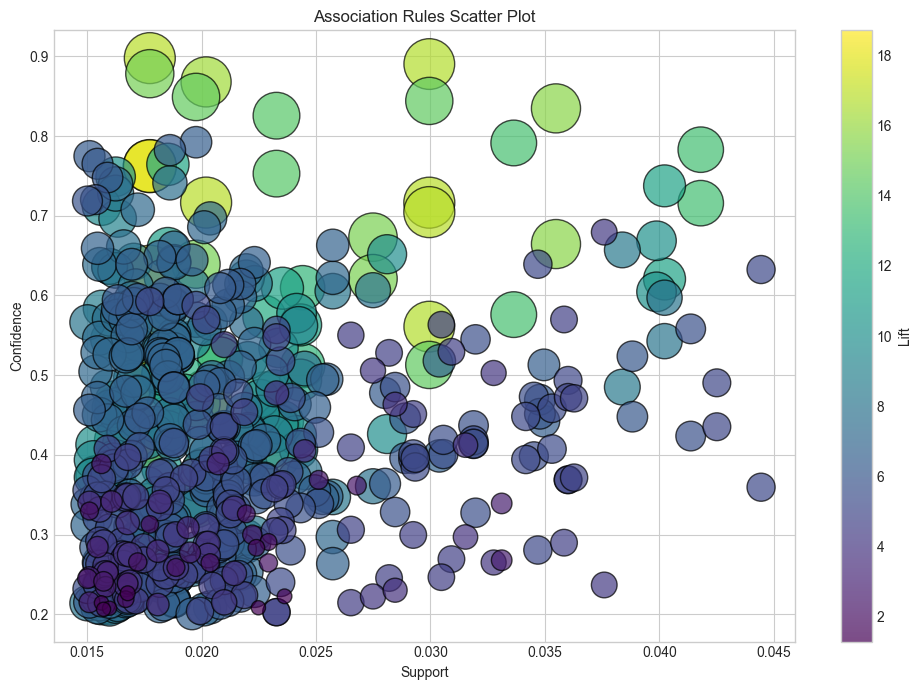

In [14]:
# 규칙이 하나라도 생성되었을 때만 정렬 및 출력 작업을 진행합니다.
if len(rules_df) > 0:
# 새로운 matplotlib figure를 생성해 현재 시각화를 시작합니다.
    plt.figure(figsize=(10, 7))
    sc = plt.scatter(
        rules_df['support'],
        rules_df['confidence'],
        s=rules_df['lift'] * 80,
        c=rules_df['lift'],
        cmap='viridis',
        alpha=0.7,
        edgecolors='black'
    )
    plt.colorbar(sc, label='Lift')
    plt.title('Association Rules Scatter Plot')
    plt.xlabel('Support')
    plt.ylabel('Confidence')
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'rules_scatter.png'), dpi=150)
    plt.show()
else:
    print('규칙이 없어 산점도를 생성하지 않습니다.')

## 14. Lift 기준 상위 규칙

In [15]:
top_lift_rules = rules_df.sort_values('lift', ascending=False).reset_index(drop=True)
if len(top_lift_rules) > 0:
    display(top_lift_rules[['rule', 'support', 'confidence', 'lift']].head(10))
else:
    print('규칙이 없습니다.')

,rule,support,confidence,lift
0,"REGENCY CAKESTAND 3 TIER, GREEN REGENCY TEACUP...",0.017741,0.629283,18.707629
1,"ROSES REGENCY TEACUP AND SAUCER, PINK REGENCY ...",0.017741,0.527415,18.707629
2,"REGENCY CAKESTAND 3 TIER, PINK REGENCY TEACUP ...",0.017741,0.762264,18.233486
3,"ROSES REGENCY TEACUP AND SAUCER, GREEN REGENCY...",0.017741,0.424370,18.233486
4,PINK REGENCY TEACUP AND SAUCER -> REGENCY CAKE...,0.017741,0.417355,17.932106
5,"REGENCY CAKESTAND 3 TIER, ROSES REGENCY TEACUP...",0.017741,0.762264,17.932106
6,"REGENCY CAKESTAND 3 TIER, GREEN REGENCY TEACUP...",0.020200,0.716511,16.855772
7,PINK REGENCY TEACUP AND SAUCER -> REGENCY CAKE...,0.020200,0.475207,16.855772
8,"ROSES REGENCY TEACUP AND SAUCER, GREEN REGENCY...",0.029949,0.716387,16.852847
9,PINK REGENCY TEACUP AND SAUCER -> ROSES REGENC...,0.029949,0.704545,16.852847


## 15. 추천 상품 함수

선택한 상품이 lhs에 포함된 규칙을 찾아 rhs의 다른 상품을 추천합니다.

In [16]:
# 특정 기준 상품을 포함하는 lhs 규칙을 바탕으로 추천 상품을 도출하는 함수를 정의합니다.
def recommend_products(selected_item, rules_df, topn=10, min_confidence=0.0):
    if len(rules_df) == 0:
        return pd.DataFrame(columns=['selected_item', 'recommended_item', 'support', 'confidence', 'lift', 'source_rule'])

# 선택 상품이 lhs에 포함된 규칙만 필터링해 추천 후보 규칙을 추출합니다.
    matched = rules_df[rules_df['lhs_items'].apply(lambda items: selected_item in items)].copy()

    if min_confidence > 0:
        matched = matched[matched['confidence'] >= min_confidence].copy()

    if len(matched) == 0:
        return pd.DataFrame(columns=['selected_item', 'recommended_item', 'support', 'confidence', 'lift', 'source_rule'])

# 추천 결과 행들을 저장할 리스트를 초기화합니다.
    rec_rows = []
# 선택 상품과 관련된 각 규칙을 순회하며 추천 후보를 생성합니다.
    for _, row in matched.iterrows():
# 현재 규칙의 rhs에 있는 각 상품을 추천 후보로 검토합니다.
        for rec_item in row['rhs_items']:
# 기준 상품 자신은 추천 대상에서 제외합니다.
            if rec_item == selected_item:
                continue
# 추천 상품, support, confidence, lift, 원본 규칙 정보를 저장합니다.
            rec_rows.append({
                'selected_item': selected_item,
                'recommended_item': rec_item,
                'support': row['support'],
                'confidence': row['confidence'],
                'lift': row['lift'],
                'source_rule': row['rule']
            })

# 누적한 추천 결과를 DataFrame으로 변환합니다.
    rec_df = pd.DataFrame(rec_rows)
    if len(rec_df) == 0:
        return pd.DataFrame(columns=['selected_item', 'recommended_item', 'support', 'confidence', 'lift', 'source_rule'])

# 추천 결과를 lift, confidence, support 기준으로 내림차순 정렬합니다.
    rec_df = rec_df.sort_values(['lift', 'confidence', 'support'], ascending=[False, False, False])
# 같은 추천 상품이 여러 규칙에서 나왔을 때 대표 규칙 하나만 남기도록 그룹화합니다.
    rec_df = rec_df.groupby(['selected_item', 'recommended_item'], as_index=False).first()
# 추천 결과를 lift, confidence, support 기준으로 내림차순 정렬합니다.
    rec_df = rec_df.sort_values(['lift', 'confidence', 'support'], ascending=[False, False, False]).reset_index(drop=True)
# 상위 topn개 추천 상품만 반환합니다.
    return rec_df.head(topn)

## 16. 추천 상품 도출

예시 기준 상품을 선택해 추천 결과를 확인합니다.

In [17]:
# 추천 결과를 살펴볼 기준 상품을 지정합니다.
TARGET_ITEM = 'WHITE HANGING HEART T-LIGHT HOLDER'
# 지정한 기준 상품이 분석 대상에 없으면 첫 번째 상품으로 대체합니다.
if TARGET_ITEM not in selected_items:
    TARGET_ITEM = selected_items[0]

# 지정한 기준 상품에 대해 추천 상품 목록을 생성합니다.
recommendations_df = recommend_products(
    selected_item=TARGET_ITEM,
    rules_df=rules_df,
    topn=10,
    min_confidence=MIN_CONFIDENCE
)

print('기준 상품:', TARGET_ITEM)
recommendations_df

기준 상품: WHITE HANGING HEART T-LIGHT HOLDER


,selected_item,recommended_item,support,confidence,lift,source_rule
0,WHITE HANGING HEART T-LIGHT HOLDER,WOODEN PICTURE FRAME WHITE FINISH,0.015633,0.712000,9.605251,"WHITE HANGING HEART T-LIGHT HOLDER, WOODEN FRA..."
1,WHITE HANGING HEART T-LIGHT HOLDER,WOODEN FRAME ANTIQUE WHITE,0.015633,0.583607,8.663552,"WHITE HANGING HEART T-LIGHT HOLDER, WOODEN PIC..."
2,WHITE HANGING HEART T-LIGHT HOLDER,RED HANGING HEART T-LIGHT HOLDER,0.037590,0.236726,4.278347,WHITE HANGING HEART T-LIGHT HOLDER -> RED HANG...


## 17. 시각화: 추천 상품 Lift

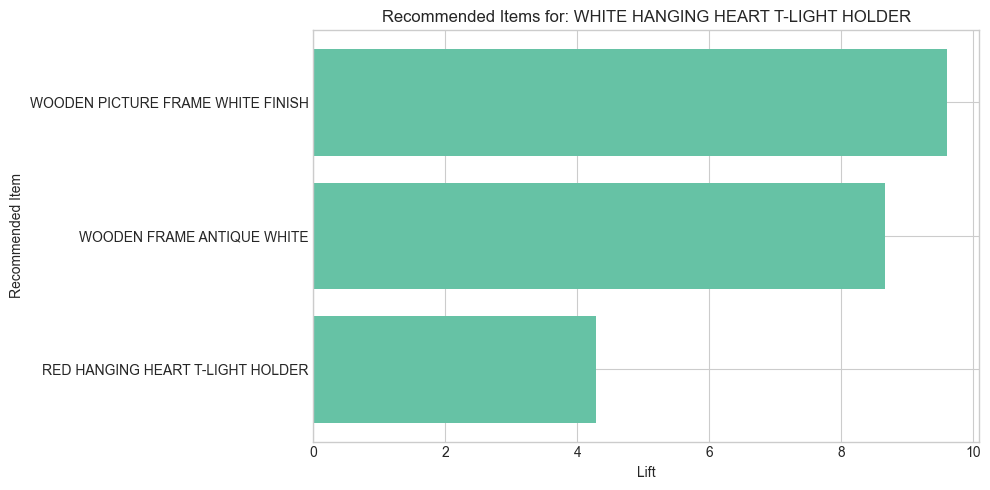

In [18]:
if len(recommendations_df) > 0:
# 새로운 matplotlib figure를 생성해 현재 시각화를 시작합니다.
    plt.figure(figsize=(10, 5))
    plot_df = recommendations_df.iloc[::-1]
# 수평 막대그래프로 support 크기를 시각화합니다.
    plt.barh(plot_df['recommended_item'], plot_df['lift'])
    plt.title(f'Recommended Items for: {TARGET_ITEM}')
    plt.xlabel('Lift')
    plt.ylabel('Recommended Item')
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'recommendations_lift.png'), dpi=150)
    plt.show()
else:
    print('추천 결과가 없습니다.')

## 18. 결과 보고서 작성

In [19]:
from IPython.display import display, Markdown

def fmt_rule(row):
    return f"{row['rule']}  |  support={row['support']:.6f}, confidence={row['confidence']:.6f}, lift={row['lift']:.6f}"

print("=" * 80)
print("UCI Online Retail 연관규칙 분석 최종 보고서")
print("=" * 80)
print()

print("1. 사용한 데이터셋 설명")
print("- 데이터셋: UCI Machine Learning Repository의 Online Retail 데이터셋")
print("- 거래 기반(InvoiceNo) 온라인 소매 데이터로, 상품명(Description), 수량(Quantity), 단가(UnitPrice), 고객ID(CustomerID), 국가(Country) 등을 포함합니다.")
print("- 취소 거래(InvoiceNo가 'C'로 시작), 결측값, 수량/단가가 0 이하인 행은 전처리 단계에서 제거했습니다.")
print("- 분석에는 영국(United Kingdom) 거래를 중심으로 장바구니 단위 거래를 구성했습니다.")
print()

print("2. 전체 거래 수")
print(f"- 원본 기준 전체 거래 수: {len(transactions):,}건")
print(f"- 분석 대상 전체 거래 수: {len(filtered_transactions):,}건")
print()

print("3. 전체 상품 수")
print(f"- 원본 기준 고유 상품 수: {df['Description'].nunique():,}개")
print(f"- 분석 대상 상위 상품 수: {len(selected_items):,}개")
print()

print("4. 가장 많이 판매된 상품")
top_item = item_counts.index[0]
top_count = int(item_counts.iloc[0])
top_support = top_count / len(transactions) if len(transactions) > 0 else 0
print(f"- 상품명: {top_item}")
print(f"- 판매 빈도: {top_count:,}건")
print(f"- Support: {top_support:.6f}")
print()

print("5. 생성된 규칙 수")
print(f"- {len(rules_df):,}개")
print()

print("6. 최고 Support 규칙")
if len(rules_df) > 0:
    best_support_rule = rules_df.sort_values(['support', 'confidence', 'lift'], ascending=[False, False, False]).iloc[0]
    print("- " + fmt_rule(best_support_rule))
else:
    print("- 생성된 규칙이 없습니다.")
print()

print("7. 최고 Confidence 규칙")
if len(rules_df) > 0:
    best_conf_rule = rules_df.sort_values(['confidence', 'lift', 'support'], ascending=[False, False, False]).iloc[0]
    print("- " + fmt_rule(best_conf_rule))
else:
    print("- 생성된 규칙이 없습니다.")
print()

print("8. 최고 Lift 규칙")
if len(rules_df) > 0:
    best_lift_rule = rules_df.sort_values(['lift', 'confidence', 'support'], ascending=[False, False, False]).iloc[0]
    print("- " + fmt_rule(best_lift_rule))
else:
    print("- 생성된 규칙이 없습니다.")
print()

print("9. 추천 시스템 결과")
print(f"- 기준 상품: {TARGET_ITEM}")
if len(recommendations_df) > 0:
    display(recommendations_df[['selected_item', 'recommended_item', 'support', 'confidence', 'lift', 'source_rule']].head(10))
else:
    print("- 추천 결과가 없습니다.")
print()

print("10. 비즈니스 활용 방안")
business_text = """
- 번들 상품 구성: 함께 자주 구매되는 상품을 세트로 묶어 객단가를 높일 수 있습니다.
- 교차판매(Cross-sell): 장바구니/상품 상세 페이지에서 연관 상품을 추천해 추가 구매를 유도할 수 있습니다.
- 프로모션 설계: lift가 높은 조합을 대상으로 쿠폰, 동시구매 할인, 묶음 할인 캠페인을 운영할 수 있습니다.
- 재고 운영: 함께 구매되는 상품군을 기준으로 재고를 동기화하거나 시즌성 수요를 예측하는 데 활용할 수 있습니다.
- 상품 진열 최적화: 오프라인/온라인 진열 순서를 연관성이 높은 상품끼리 배치해 탐색 효율을 높일 수 있습니다.
"""
print(business_text.strip())

print("=" * 80)

UCI Online Retail 연관규칙 분석 최종 보고서

1. 사용한 데이터셋 설명
- 데이터셋: UCI Machine Learning Repository의 Online Retail 데이터셋
- 거래 기반(InvoiceNo) 온라인 소매 데이터로, 상품명(Description), 수량(Quantity), 단가(UnitPrice), 고객ID(CustomerID), 국가(Country) 등을 포함합니다.
- 취소 거래(InvoiceNo가 'C'로 시작), 결측값, 수량/단가가 0 이하인 행은 전처리 단계에서 제거했습니다.
- 분석에는 영국(United Kingdom) 거래를 중심으로 장바구니 단위 거래를 구성했습니다.

2. 전체 거래 수
- 원본 기준 전체 거래 수: 15,373건
- 분석 대상 전체 거래 수: 11,386건

3. 전체 상품 수
- 원본 기준 고유 상품 수: 3,833개
- 분석 대상 상위 상품 수: 120개

4. 가장 많이 판매된 상품
- 상품명: WHITE HANGING HEART T-LIGHT HOLDER
- 판매 빈도: 1,866건
- Support: 0.121382

5. 생성된 규칙 수
- 648개

6. 최고 Support 규칙
- JUMBO BAG PINK POLKADOT -> JUMBO BAG RED RETROSPOT  |  support=0.044441, confidence=0.632500, lift=5.114805

7. 최고 Confidence 규칙
- REGENCY CAKESTAND 3 TIER, ROSES REGENCY TEACUP AND SAUCER, PINK REGENCY TEACUP AND SAUCER -> GREEN REGENCY TEACUP AND SAUCER  |  support=0.017741, confidence=0.897778, lift=16.812661

8. 최고 Lift 규칙
- REGENCY CAKESTAND 3 TIER, GREEN REGENCY TEACUP AND SAUCER -> ROS

,selected_item,recommended_item,support,confidence,lift,source_rule
0,WHITE HANGING HEART T-LIGHT HOLDER,WOODEN PICTURE FRAME WHITE FINISH,0.015633,0.712000,9.605251,"WHITE HANGING HEART T-LIGHT HOLDER, WOODEN FRA..."
1,WHITE HANGING HEART T-LIGHT HOLDER,WOODEN FRAME ANTIQUE WHITE,0.015633,0.583607,8.663552,"WHITE HANGING HEART T-LIGHT HOLDER, WOODEN PIC..."
2,WHITE HANGING HEART T-LIGHT HOLDER,RED HANGING HEART T-LIGHT HOLDER,0.037590,0.236726,4.278347,WHITE HANGING HEART T-LIGHT HOLDER -> RED HANG...



10. 비즈니스 활용 방안
- 번들 상품 구성: 함께 자주 구매되는 상품을 세트로 묶어 객단가를 높일 수 있습니다.
- 교차판매(Cross-sell): 장바구니/상품 상세 페이지에서 연관 상품을 추천해 추가 구매를 유도할 수 있습니다.
- 프로모션 설계: lift가 높은 조합을 대상으로 쿠폰, 동시구매 할인, 묶음 할인 캠페인을 운영할 수 있습니다.
- 재고 운영: 함께 구매되는 상품군을 기준으로 재고를 동기화하거나 시즌성 수요를 예측하는 데 활용할 수 있습니다.
- 상품 진열 최적화: 오프라인/온라인 진열 순서를 연관성이 높은 상품끼리 배치해 탐색 효율을 높일 수 있습니다.
